# HW 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.stem import PorterStemmer
import spacy
from tqdm.auto import tqdm
from transformers import BertTokenizerFast

### Загрузка данных

Датасет wikIR1k скачан вручную с [Zenodo](https://zenodo.org/records/3565761) и распакован в `data/wikIR1k/`.

```bash
curl -L "https://zenodo.org/records/3565761/files/wikIR1k.zip?download=1" -o wikIR1k.zip
unzip wikIR1k.zip
```

In [4]:
df = pd.read_csv("data/wikIR1k/documents.csv")
df.head()

,id_right,text_right
0,1781133,it was used in landing craft during world war ...
1,2426736,after rejecting an offer from cambridge univer...
2,2224122,mat zan coached kuala lumpur fa in 1999 and wo...
3,219642,a barcode is a machine readable optical label ...
4,1728654,since the subordination of the monarchy under ...


### Provide basic collection stats

In [5]:
TEXT_COL = "text_right"

# Разбиваем текст каждого документа на слова
doc_words = df[TEXT_COL].astype(str).str.split()
doc_lengths = doc_words.apply(len)

In [6]:
# 1. Количество документов
n_documents = len(df)
print(f"1. # documents: {n_documents}")

1. # documents: 369721


In [7]:
# 2. Размер коллекции в словах
collection_size = doc_lengths.sum()
print(f"2. Collection size in words: {collection_size}")

2. Collection size in words: 73093729


In [8]:
# 3. Средняя длина документа в словах
avg_doc_length = doc_lengths.mean()
print(f"3. Avg. document length in words: {avg_doc_length:.2f}")

3. Avg. document length in words: 197.70


In [9]:
# 4. Количество уникальных слов
all_words = doc_words.explode()
unique_words = all_words.unique()
n_unique_words = len(unique_words)
print(f"4. # unique words (types): {n_unique_words}")

4. # unique words (types): 794568


In [10]:
# 5. Средняя длина слова
avg_word_length = all_words.str.len().mean()
print(f"5. Avg. word length: {avg_word_length:.2f}")

5. Avg. word length: 4.80


In [11]:
# 6. Средняя длина уникального слова
avg_type_length = np.mean([len(w) for w in unique_words])
print(f"6. Avg. unique word (type) length: {avg_type_length:.2f}")

6. Avg. unique word (type) length: 7.71


### Summary

In [12]:

print("Basic Collection Stats")
print(f"1. # documents:                  {n_documents}")
print(f"2. Collection size in words:     {collection_size}")
print(f"3. Avg. document length (words): {avg_doc_length:.2f}")
print(f"4. # unique words (types):       {n_unique_words}")
print(f"5. Avg. word length:             {avg_word_length:.2f}")
print(f"6. Avg. unique word length:      {avg_type_length:.2f}")

Basic Collection Stats
1. # documents:                  369721
2. Collection size in words:     73093729
3. Avg. document length (words): 197.70
4. # unique words (types):       794568
5. Avg. word length:             4.80
6. Avg. unique word length:      7.71


## Build a frequency list

### 1. Частотный список слов

In [13]:
# Строим частотный список - уникальные слова + их частоты, отсортированные по убыванию
word_freq = all_words.value_counts()
print(f"Всего уникальных слов: {len(word_freq)}")
print("\nТоп-30 самых частых слов:")
word_freq.head(30)

Всего уникальных слов: 794568

Топ-30 самых частых слов:


text_right
the      5311943
of       2532382
in       2355417
and      2231007
a        1557760
to       1407261
was      1078183
he        685303
is        676829
as        661622
for       616110
on        610583
with      535843
by        526627
s         497472
at        482839
his       440633
from      432326
it        398308
that      306808
an        279228
which     221057
first     217204
are       206921
were      205684
has       195167
also      186055
she       184297
after     166616
its       161439
Name: count, dtype: int64

### 2. Анализ стоп-слов

Список стоп-слов взят из [NLTK](https://gist.github.com/sebleier/554280).

In [14]:
# Список стоп-слов NLTK
stopwords = set([
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you",
    "your", "yours", "yourself", "yourselves", "he", "him", "his",
    "himself", "she", "her", "hers", "herself", "it", "its", "itself",
    "they", "them", "their", "theirs", "themselves", "what", "which",
    "who", "whom", "this", "that", "these", "those", "am", "is", "are",
    "was", "were", "be", "been", "being", "have", "has", "had", "having",
    "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if",
    "or", "because", "as", "until", "while", "of", "at", "by", "for",
    "with", "about", "against", "between", "into", "through", "during",
    "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further",
    "then", "once", "here", "there", "when", "where", "why", "how",
    "all", "any", "both", "each", "few", "more", "most", "other",
    "some", "such", "no", "nor", "not", "only", "own", "same", "so",
    "than", "too", "very", "s", "t", "can", "will", "just", "don",
    "should", "now",
])

# Сколько вхождений стоп-слов в коллекции
stopword_occurrences = word_freq[word_freq.index.isin(stopwords)].sum()
print(f"Вхождений стоп-слов в коллекции: {stopword_occurrences}")
print(f"Доля стоп-слов: {stopword_occurrences / collection_size:.2%}")


Вхождений стоп-слов в коллекции: 29387785
Доля стоп-слов: 40.21%


In [15]:
# Все ли топ-30 слов входят в список стоп-слов?
top30 = word_freq.head(30)
top30_in_stopwords = top30.index.isin(stopwords)

print(f"\nТоп-30 слов и их принадлежность к стоп-словам:")
for word, freq, is_stop in zip(top30.index, top30.values, top30_in_stopwords):
    marker = "Входит" if is_stop else "Не входит"
    print(f"  {marker} {word:15s} {freq:>10,}")

not_in_stopwords = top30.index[~top30_in_stopwords].tolist()
print(f"\nТоп слов (из топ 30), не входящих в стоп-лист: {not_in_stopwords}")


Топ-30 слов и их принадлежность к стоп-словам:
  Входит the              5,311,943
  Входит of               2,532,382
  Входит in               2,355,417
  Входит and              2,231,007
  Входит a                1,557,760
  Входит to               1,407,261
  Входит was              1,078,183
  Входит he                 685,303
  Входит is                 676,829
  Входит as                 661,622
  Входит for                616,110
  Входит on                 610,583
  Входит with               535,843
  Входит by                 526,627
  Входит s                  497,472
  Входит at                 482,839
  Входит his                440,633
  Входит from               432,326
  Входит it                 398,308
  Входит that               306,808
  Входит an                 279,228
  Входит which              221,057
  Не входит first              217,204
  Входит are                206,921
  Входит were               205,684
  Входит has                195,167
  Не входит a

In [16]:
# Топ-30 частых слов, не входящих в стоп-лист
non_stop_freq = word_freq[~word_freq.index.isin(stopwords)]
print("Топ-30 частых слов, НЕ входящих в стоп-лист:")
for i, (word, freq) in enumerate(non_stop_freq.head(30).items(), 1):
    print(f"  {i:2d}. {word:15s} {freq:>10,}")

Топ-30 частых слов, НЕ входящих в стоп-лист:
   1. first              217,204
   2. also               186,055
   3. one                157,573
   4. new                139,850
   5. two                136,427
   6. school             119,897
   7. university         107,386
   8. time                95,373
   9. 1                   89,967
  10. years               88,565
  11. year                85,032
  12. later               80,738
  13. became              80,151
  14. city                77,682
  15. world               77,013
  16. three               76,155
  17. known               73,969
  18. state               70,280
  19. national            69,849
  20. part                69,635
  21. united              68,263
  22. 2                   67,911
  23. born                66,729
  24. made                65,449
  25. team                64,448
  26. may                 62,403
  27. season              61,403
  28. second              61,249
  29. south               60,50

In [17]:
# Топ-50 слов до 4 символов, не входящих в стоп-лист
short_non_stop = non_stop_freq[non_stop_freq.index.str.len() <= 4]
print("Топ-50 коротких слов (≤4 символов), НЕ входящих в стоп-лист:")
for i, (word, freq) in enumerate(short_non_stop.head(50).items(), 1):
    print(f"  {i:2d}. {word:15s} {freq:>10,}")

Топ-50 коротких слов (≤4 символов), НЕ входящих в стоп-лист:
   1. also               186,055
   2. one                157,573
   3. new                139,850
   4. two                136,427
   5. time                95,373
   6. 1                   89,967
   7. year                85,032
   8. city                77,682
   9. part                69,635
  10. 2                   67,911
  11. born                66,729
  12. made                65,449
  13. team                64,448
  14. may                 62,403
  15. high                60,138
  16. war                 59,899
  17. name                59,590
  18. used                59,302
  19. area                59,139
  20. film                58,273
  21. many                56,998
  22. well                55,208
  23. 3                   54,015
  24. work                50,255
  25. four                49,699
  26. won                 48,847
  27. 5                   46,333
  28. de                  46,275
  29. 4        

### Рекомендация по расширению стоп-листа

Из топ-30 самых частых слов коллекции **28 из 30** входят в стоп-лист. Не входят только `first` (217k) и `also` (186k).

Анализ частых слов вне стоп-листа позволяет выделить несколько групп кандидатов на добавление:

**Рекомендуется добавить:**

| Категория | Слова | Обоснование |
|---|---|---|
| Функциональные слова / наречия | `also`, `one`, `many`, `well` | Встречаются часто, не несут специфической тематической семантики |
| Числительные (словом) | `two`, `three`, `four` | Общеупотребительные числительные, не помогают различать документы по теме |
| Цифры и числа | `1`, `2`, `3`, `4`, `5`, `6`, `10`, `000` | Не несут тематической информации, засоряют индекс |
| Одиночные буквы | `d`, `m` | Вероятные артефакты токенизации (из сокращений, инициалов) |
| Служебные элементы | `de` | Частица из иноязычных имён (напр. "de la"), не полезна для английского поиска |

**Не рекомендуется добавлять:**

| Категория | Слова | Обоснование |
|---|---|---|
| Тематические существительные | `school`, `university`, `city`, `world`, `state`, `war` | Несут содержательную семантику, помогают отличать документы по теме |
| Доменные слова | `film`, `team`, `song`, `game`, `club` | Характеризуют конкретные тематические области коллекции |

**Пограничные случаи:** слова `first`, `new`, `time`, `year` — очень частые и достаточно общие, но могут быть частью осмысленных запросов / устойчивых выражений или значений  ( "first world war", "new york" и тд).

**Вывод:** стоп-лист NLTK (https://gist.github.com/sebleier/554280) покрывает основные служебные слова, но его стоит расширить цифрами, числительными и  функциональными наречиями. При этом тематические слова, даже очень частые, удалять не следует — они важны для различения документов.

### 3. Проверяем закон Ципфа (Zipf's law)

Параметры закона Ципфа (f = C / r^α):
  α = 1.4479
  C = 232,833,414
  R² = 0.981450


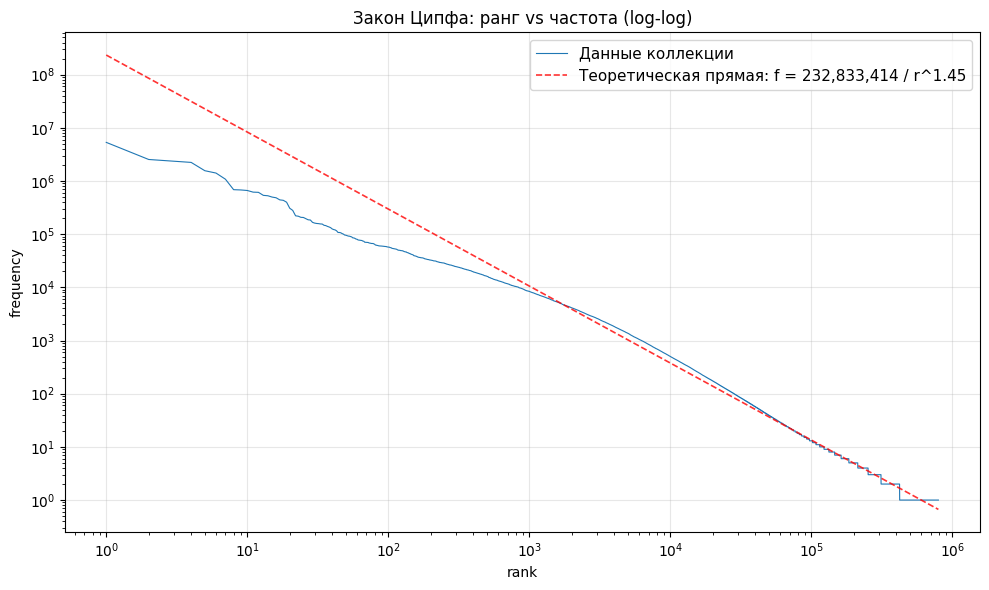

In [18]:
# Закон Ципфа: ранг vs частота в лог-лог координатах
ranks = np.arange(1, len(word_freq) + 1)
freqs = word_freq.values

# Линейная регрессия в лог-лог пространстве: log(f) = log(C) - α·log(r)
log_ranks = np.log10(ranks)
log_freqs = np.log10(freqs)
alpha, log_C = np.polyfit(log_ranks, log_freqs, 1)
C = 10 ** log_C

print(f"Параметры закона Ципфа (f = C / r^α):")
print(f"  α = {-alpha:.4f}")
print(f"  C = {C:,.0f}")
print(f"  R² = {np.corrcoef(log_ranks, log_freqs)[0,1]**2:.6f}")

# Теоретическая прямая Ципфа
zipf_fit = C * ranks.astype(float) ** alpha

plt.figure(figsize=(10, 6))
plt.loglog(ranks, freqs, linewidth=0.8, label="Данные коллекции")
plt.loglog(ranks, zipf_fit, '--', color='red', linewidth=1.2, alpha=0.8,
           label=f"Теоретическая прямая: f = {C:,.0f} / r^{-alpha:.2f}")
plt.xlabel("rank")
plt.ylabel("frequency")
plt.title("Закон Ципфа: ранг vs частота (log-log)")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Выводы по закону Ципфа

Закон Ципфа в целом подтверждается: R² = 0.98, зависимость ранг–частота близка к прямой в лог-лог координатах.

Полученный показатель α = 1.45 выше классического значения 1, что означает более резкий спад частоты с ростом ранга. Это видно на графике: теоретическая прямая завышает частоты в голове.

### 4. Закон Хипса (Heaps' law)

Параметры закона Хипса (V = k · n^β):
  k = 5.01
  β = 0.6781
  R² = 0.992913


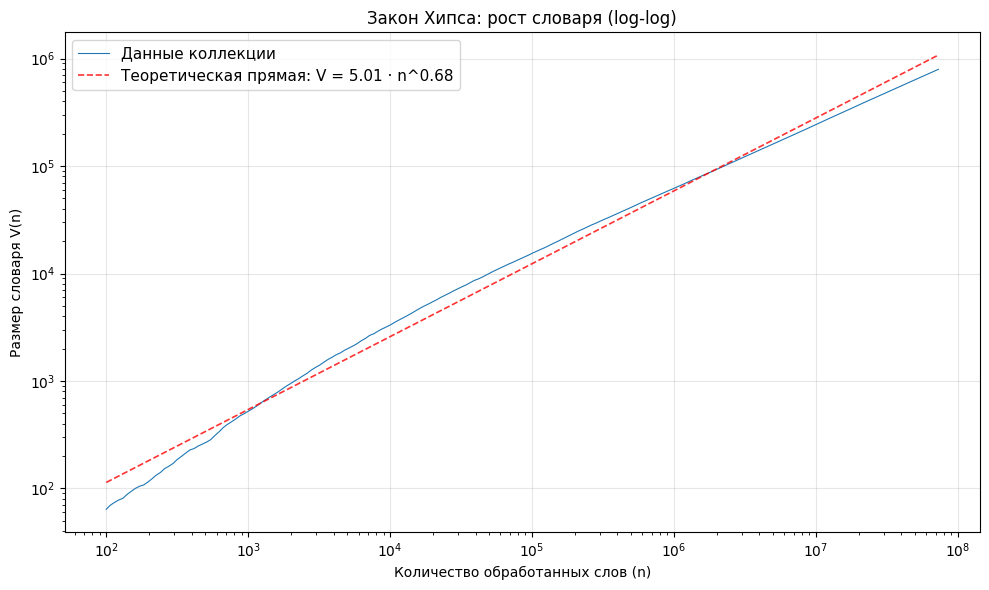

In [19]:
# Закон Хипса - рост словаря по мере обработки коллекции
# Сэмплируем точки
sample_points = np.logspace(2, np.log10(collection_size), num=200, dtype=int)
sample_points = np.unique(sample_points)  # убираем дубликаты

# Собираем все слова в один массив (по документам)
all_words_array = all_words.values

vocab = set()
vocab_sizes = []
word_counts = []
prev_idx = 0

for target in sample_points:
    vocab.update(all_words_array[prev_idx:target])
    prev_idx = target
    word_counts.append(target)
    vocab_sizes.append(len(vocab))

# Линейная регрессия в лог-лог пространстве
log_n = np.log10(word_counts)
log_v = np.log10(vocab_sizes)
beta, log_k = np.polyfit(log_n, log_v, 1)
k = 10 ** log_k

print(f"Параметры закона Хипса (V = k · n^β):")
print(f"  k = {k:.2f}")
print(f"  β = {beta:.4f}")
print(f"  R² = {np.corrcoef(log_n, log_v)[0,1]**2:.6f}")

# Теоретическая прямая Хипса
heaps_fit = k * np.array(word_counts, dtype=float) ** beta

plt.figure(figsize=(10, 6))
plt.loglog(word_counts, vocab_sizes, linewidth=0.8, label="Данные коллекции")
plt.loglog(word_counts, heaps_fit, '--', color='red', linewidth=1.2, alpha=0.8,
           label=f"Теоретическая прямая: V = {k:.2f} · n^{beta:.2f}")
plt.xlabel("Количество обработанных слов (n)")
plt.ylabel("Размер словаря V(n)")
plt.title("Закон Хипса: рост словаря (log-log)")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Выводы по закону Хипса

Закон Хипса подтверждается: R² = 0.99, рост словаря хорошо описывается степенной зависимостью $V(n) = 5.01 \cdot n^{0.68}$.

## Build a frequency list of word bigrams

In [20]:
# Строим биграммы внутри каждого документа (не пересекая границы документов)
def get_bigrams(words):
    return [f"{words[i]} {words[i+1]}" for i in range(len(words) - 1)]

doc_bigrams = doc_words.apply(get_bigrams)
all_bigrams = doc_bigrams.explode()

bigram_freq = all_bigrams.value_counts()
print(f"1. Уникальных биграмм в коллекции: {len(bigram_freq):,}")
print(f"   Всего вхождений биграмм: {bigram_freq.sum():,}")
print(f"\nТоп-30 самых частых биграмм:")
for i, (bigram, freq) in enumerate(bigram_freq.head(30).items(), 1):
    print(f"  {i:2d}. {bigram:25s} {freq:>10,}")

1. Уникальных биграмм в коллекции: 12,993,004
   Всего вхождений биграмм: 72,724,008

Топ-30 самых частых биграмм:
   1. of the                       768,320
   2. in the                       546,863
   3. to the                       256,451
   4. at the                       201,351
   5. and the                      170,394
   6. on the                       169,708
   7. he was                       163,554
   8. as a                         163,073
   9. for the                      159,502
  10. by the                       130,810
  11. with the                     120,118
  12. from the                     115,219
  13. the first                    104,264
  14. it was                       101,387
  15. as the                        96,915
  16. it is                         95,880
  17. is a                          82,161
  18. was a                         78,342
  19. in a                          76,786
  20. one of                        70,278
  21. was the            

In [21]:
# 2. Анализ топа: разделяем биграммы на категории
# Биграмма — кандидат в словарь инвертированного индекса, если оба слова содержательные
top100 = bigram_freq.head(100)

both_stop = []
one_stop = []
no_stop = []

for bigram, freq in top100.items():
    w1, w2 = bigram.split()
    s1 = w1 in stopwords
    s2 = w2 in stopwords
    if s1 and s2:
        both_stop.append((bigram, freq))
    elif s1 or s2:
        one_stop.append((bigram, freq))
    else:
        no_stop.append((bigram, freq))

print(f"Из топ-100 биграмм:")
print(f"  Оба слова — стоп-слова:       {len(both_stop)}")
print(f"  Одно слово — стоп-слово:      {len(one_stop)}")
print(f"  Без стоп-слов:                {len(no_stop)}")

print(f"\n--- Биграммы БЕЗ стоп-слов (кандидаты в словарь) ---")
for i, (bigram, freq) in enumerate(no_stop, 1):
    print(f"  {i:2d}. {bigram:25s} {freq:>10,}")

Из топ-100 биграмм:
  Оба слова — стоп-слова:       56
  Одно слово — стоп-слово:      40
  Без стоп-слов:                4

--- Биграммы БЕЗ стоп-слов (кандидаты в словарь) ---
   1. united states                 48,952
   2. new york                      38,477
   3. high school                   29,895
   4. world war                     20,915


In [22]:
# Топ-50 биграмм без стоп-слов (расширенный список для анализа)
no_stop_bigrams = bigram_freq[
    bigram_freq.index.map(lambda b: not any(w in stopwords for w in b.split()))
]
print(f"Всего биграмм без стоп-слов: {len(no_stop_bigrams):,}")
print(f"\nТоп-50 биграмм без стоп-слов:")
for i, (bigram, freq) in enumerate(no_stop_bigrams.head(50).items(), 1):    print(f"  {i:2d}. {bigram:25s} {freq:>10,}")

Всего биграмм без стоп-слов: 9,195,746

Топ-50 биграмм без стоп-слов:
   1. united states                 48,952
   2. new york                      38,477
   3. high school                   29,895
   4. world war                     20,915
   5. war ii                        10,432
   6. york city                     10,401
   7. los angeles                   10,042
   8. two years                      9,013
   9. new zealand                    8,764
  10. years later                    7,412
  11. best known                     7,391
  12. also known                     7,198
  13. united kingdom                 6,924
  14. 19th century                   6,721
  15. first time                     6,640
  16. state university               6,199
  17. air force                      6,145
  18. took place                     6,045
  19. year old                       6,025
  20. san francisco                  5,897
  21. years old                      5,690
  22. following year       

#### Проверяем формально коллокационность топ-50 биграмм без стоп-слов с помощью PMI, t-test и χ²

In [23]:
# Считаем PMI, t-test и χ² для топ-50 биграмм без стоп-слов
N = bigram_freq.sum()  # всего биграмм

top50 = no_stop_bigrams.head(50)
results = []

for bigram, freq_bi in top50.items():
    w1, w2 = bigram.split()
    freq_w1 = word_freq.get(w1, 0)
    freq_w2 = word_freq.get(w2, 0)
    
    # Вероятности
    p_bi = freq_bi / N
    p_w1 = freq_w1 / N
    p_w2 = freq_w2 / N
    
    # PMI = log2(P(w1w2) / (P(w1) * P(w2)))
    expected = p_w1 * p_w2
    pmi = np.log2(p_bi / expected) if expected > 0 else 0
    
    # t-test: t = (observed - expected) / sqrt(observed / N)
    t_score = (p_bi - expected) / np.sqrt(p_bi / N)
    
    # χ²: таблица 2×2
    o11 = freq_bi
    o12 = freq_w1 - freq_bi
    o21 = freq_w2 - freq_bi
    o22 = N - freq_w1 - freq_w2 + freq_bi
    
    e11 = freq_w1 * freq_w2 / N
    e12 = freq_w1 * (N - freq_w2) / N
    e21 = (N - freq_w1) * freq_w2 / N
    e22 = (N - freq_w1) * (N - freq_w2) / N
    
    chi2 = ((o11-e11)**2/e11 + (o12-e12)**2/e12 + (o21-e21)**2/e21 + (o22-e22)**2/e22)
    
    results.append((bigram, freq_bi, pmi, t_score, chi2))

print(f"{'Биграмма':25s} {'Частота':>8s} {'PMI':>8s} {'t-test':>10s} {'χ²':>14s}")
print("-" * 70)
for bigram, freq, pmi, t, chi2 in results:
    print(f"{bigram:25s} {freq:>8,} {pmi:>8.2f} {t:>10.1f} {chi2:>14,.0f}")

Биграмма                   Частота      PMI     t-test             χ²
----------------------------------------------------------------------
united states               48,952     9.77      221.0     42,700,022
new york                    38,477     8.92      195.8     18,642,560
high school                 29,895     8.24      172.3      8,976,521
world war                   20,915     8.37      144.2      6,867,357
war ii                      10,432     9.01      101.9      5,382,106
york city                   10,401     7.88      101.6      2,439,662
los angeles                 10,042    12.56      100.2     60,682,708
two years                    9,013     5.76       93.2        472,539
new zealand                  8,764     9.01       93.4      4,511,470
years later                  7,412     6.24       85.0        545,281
best known                   7,391     7.67       85.5      1,490,354
also known                   7,198     5.25       82.6        260,509
united kingdom     

- *hong kong*, *los angeles*, *san francisco* — настоящие коллокации (высокий PMI + значимый t-test)
- *united states*, *new york* — и частые, и устойчивые (всё высокое)
- *two years*, *one year*, *first time* — просто частые соседи, не коллокации (низкий PMI). Их в словарь индекса добавлять не стоит

### 2. Анализ топа биграмм: какие хранить в индексе?

Из топ-100 биграмм 56 состоят целиком из стоп-слов ("of the", "in a"), ещё 40 содержат одно стоп-слово ("the first", "the united"). Только 4 биграммы не содержат стоп-слов: *united states*, *new york*, *high school*, *world war*.

**Критерии отбора биграмм в словарь инвертированного индекса:**

1. **Оба слова содержательные** — биграммы из стоп-слов ("of the", "was a") не несут тематической информации.

2. **Устойчивое словосочетание (коллокация)** — частота биграммы значительно выше, чем ожидалось бы при независимом появлении слов. Формально можно проверить метриками PMI, chi-squared или t-test.

3. **Единое понятие** — значение биграммы не сводится к сумме значений слов:
   - Географические названия: *new york*, *los angeles*...
   - Страны/регионы: *united states*, *united kingdom*, *south africa*...
   - Устойчивые термины: *world war*, *high school*...

4. **Полезность для поиска** — пользователь ищет словосочетание как единое целое. Поиск "new york" как одного термина точнее, чем пересечение постингов "new" и "york".

**Не стоит добавлять:**
- Биграммы со стоп-словами ("of the", "in the", "was a")
- Сочетания общих слов, не образующие единого понятия ("two years", "years later", "years old")

## Morphological processing

### 1. Using NLTK’s implementation of the Porter [stemmer](https://www.nltk.org/api/nltk.stem.porter.html) to stem the collection

In [24]:
stemmer = PorterStemmer()

# Стеммим только уникальные слова (795k вместо 73M) и маппим обратно
unique_words_list = all_words.unique()
stem_map = {w: stemmer.stem(w) for w in tqdm(unique_words_list, desc="Стемминг уникальных слов")}
all_stems = all_words.map(stem_map)

doc_stems = doc_words.apply(lambda words: [stem_map[w] for w in words])
doc_stem_lengths = doc_stems.apply(len)

stem_freq = all_stems.value_counts()

print(f"Уникальных стемов: {len(stem_freq):,}")
print(f"\nТоп-30 стемов:")
for i, (stem, freq) in enumerate(stem_freq.head(30).items(), 1):
    print(f"  {i:2d}. {stem:15s} {freq:>10,}")

Стемминг уникальных слов: 100%|██████████| 794568/794568 [00:04<00:00, 172581.12it/s]


Уникальных стемов: 684,579

Топ-30 стемов:
   1. the              5,311,951
   2. of               2,532,399
   3. in               2,355,803
   4. and              2,231,408
   5. a                1,557,780
   6. to               1,407,364
   7. wa               1,078,880
   8. he                 685,329
   9. is                 676,829
  10. as                 661,622
  11. for                616,136
  12. on                 610,695
  13. it                 559,747
  14. with               535,853
  15. by                 526,637
  16. s                  497,472
  17. at                 482,918
  18. hi                 441,276
  19. from               432,326
  20. that               306,813
  21. an                 279,602
  22. which              221,058
  23. first              217,301
  24. are                207,051
  25. were               205,687
  26. be                 199,512
  27. ha                 196,710
  28. also               186,063
  29. she                184,302


### 2. Lemmatization (spaCy, en_core_web_sm)

In [25]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Лемматизация батчами через nlp.pipe
texts = df[TEXT_COL].astype(str).tolist()
doc_lemmas = []
for doc in tqdm(nlp.pipe(texts, batch_size=500, n_process=16), total=len(texts), desc="Лемматизация"):
    doc_lemmas.append([token.lemma_.lower() for token in doc])

doc_lemmas = pd.Series(doc_lemmas)
doc_lemma_lengths = doc_lemmas.apply(len)

all_lemmas = doc_lemmas.explode()
lemma_freq = all_lemmas.value_counts()

print(f"Уникальных лемм: {len(lemma_freq):,}")
print(f"\nТоп-30 лемм:")
for i, (lemma, freq) in enumerate(lemma_freq.head(30).items(), 1):
    print(f"  {i:2d}. {lemma:15s} {freq:>10,}")

Лемматизация: 100%|██████████| 369721/369721 [31:34<00:00, 195.14it/s] 


Уникальных лемм: 758,816

Топ-30 лемм:
   1. the              5,311,955
   2. of               2,532,384
   3. be               2,476,539
   4. in               2,355,842
   5. and              2,231,008
   6. a                1,557,821
   7. to               1,407,711
   8. he                 738,314
   9. as                 661,622
  10. for                616,134
  11. on                 610,651
  12. with               535,846
  13. by                 526,627
  14. s                  497,596
  15. at                 482,904
  16. have               471,292
  17. his                440,637
  18. from               432,326
  19. it                 398,313
  20. that               306,811
  21. an                 279,358
  22. which              221,058
  23. first              217,301
  24. she                207,415
  25. also               186,055
  26. year               173,591
  27. after              166,623
  28. its                161,439
  29. one                160,072
  30

### 3. BERT Tokenizer

In [26]:
bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# Батчевая токенизация через Rust-токенизатор
texts = df[TEXT_COL].astype(str).tolist()
batch_size = 10000
doc_bert_tokens = []

for i in tqdm(range(0, len(texts), batch_size), desc="BERT токенизация"):
    batch = texts[i:i+batch_size]
    encoded = bert_tokenizer(batch, add_special_tokens=False)
    for ids in encoded["input_ids"]:
        doc_bert_tokens.append(bert_tokenizer.convert_ids_to_tokens(ids))

doc_bert_tokens = pd.Series(doc_bert_tokens)
doc_bert_lengths = doc_bert_tokens.apply(len)

all_bert_tokens = doc_bert_tokens.explode()
bert_freq = all_bert_tokens.value_counts()

print(f"BERT-токенизация завершена.")
print(f"Уникальных токенов: {len(bert_freq):,}")
print(f"\nТоп-30 токенов:")
for i, (token, freq) in enumerate(bert_freq.head(30).items(), 1):
    print(f"  {i:2d}. {token:15s} {freq:>10,}")

BERT токенизация: 100%|██████████| 37/37 [03:38<00:00,  5.91s/it]


BERT-токенизация завершена.
Уникальных токенов: 27,528

Топ-30 токенов:
   1. the              5,316,027
   2. of               2,533,371
   3. in               2,368,241
   4. and              2,236,044
   5. a                1,565,150
   6. to               1,415,684
   7. was              1,079,359
   8. he                 698,933
   9. is                 682,438
  10. as                 672,783
  11. for                619,002
  12. on                 614,154
  13. with               536,652
  14. by                 528,773
  15. s                  505,495
  16. at                 490,899
  17. his                442,519
  18. from               432,612
  19. it                 401,704
  20. ##s                350,577
  21. that               307,104
  22. an                 291,438
  23. which              221,092
  24. first              217,512
  25. are                207,715
  26. were               205,813
  27. has                197,564
  28. she                189,745
  29

Предупреждение о длине > 512 — это нормально. BERT-модель принимает максимум 512 токенов, но мы используем только токенизатор, а не саму модель. Токенизатор справляется с любой длиной.

### 4. Сравнение: базовая статистика

In [28]:
# Сравнительная таблица статистик
versions = {
    "Оригинал": (all_words, doc_lengths, word_freq),
    "Porter Stemmer": (all_stems, doc_stem_lengths, stem_freq),
    "spaCy Lemmatizer": (all_lemmas, doc_lemma_lengths, lemma_freq),
    "BERT Tokenizer": (all_bert_tokens, doc_bert_lengths, bert_freq),
}

print(f"{'Метрика':<35s} {'Оригинал':>12s} {'Stemmer':>12s} {'Lemmatizer':>12s} {'BERT':>12s}")
print("-" * 87)

rows = []
for label, getter in [
    ("Всего токенов", lambda name, v: f"{v[0].shape[0]:,}"),
    ("Уникальных токенов (types)", lambda name, v: f"{len(v[2]):,}"),
    ("Сжатие словаря, %", lambda name, v: f"{(1 - len(v[2]) / len(word_freq)) * 100:.1f}%" if name != "Оригинал" else "—"),
    ("Ср. длина документа (токенов)", lambda name, v: f"{v[1].mean():.1f}"),
    ("Ср. длина токена (символов)", lambda name, v: f"{v[0].str.len().mean():.2f}"),
]:
    vals = []
    for name, v in versions.items():
        vals.append(getter(name, v))
    print(f"{label:<35s} {vals[0]:>12s} {vals[1]:>12s} {vals[2]:>12s} {vals[3]:>12s}")

Метрика                                 Оригинал      Stemmer   Lemmatizer         BERT
---------------------------------------------------------------------------------------
Всего токенов                         73,093,729   73,093,729   73,106,364   81,185,427
Уникальных токенов (types)               794,568      684,579      758,816       27,528
Сжатие словаря, %                              —        13.8%         4.5%        96.5%
Ср. длина документа (токенов)              197.7        197.7        197.7        219.6
Ср. длина токена (символов)                 4.80         4.26         4.59         4.52


### Выводы по морфологической обработке

**Porter Stemmer** — сжатие словаря на 13.8% (794k → 685k). Количество токенов не меняется — стеммер просто обрезает окончания 

**spaCy Lemmatizer** — сжатие всего 4.5% (794k → 759k). Лемматизатор аккуратнее: приводит слова к словарной форме с учётом части речи , но не склеивает далёкие формы. Чуть больше токенов (73.1M vs 73.0M) — spaCy иначе разбивает некоторые слова.

**BERT WordPiece** — радикальное сжатие словаря: 96.5% (794k → 27.5k фиксированных токенов). Цена — увеличение общего числа токенов на 11% (73M → 81M), так как редкие слова дробятся на подслова. Средняя длина документа выросла с 197.7 до 219.6 токенов.

**Компромисс**: стеммер и лемматизатор уменьшают словарь, не увеличивая длину текста. BERT минимизирует словарь, но раздувает текст. Для классического инвертированного индекса лучше стемминг/лемматизация; BERT-токенизация предназначена для нейросетевых моделей.